# 04. Construcción de la red bipartita autor-video

La red es no dirigida y tiene dos particiones: autores y videos. Todos los nodos y todas las
aristas observadas se conservan en la visualización.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

# Busca los CSV sin depender de una ruta absoluta del equipo
def localizar_archivo(nombre):
    candidatos = [
        Path.cwd() / nombre,
        Path.cwd() / "data" / nombre,
        Path.cwd() / "upload" / nombre,
        Path.cwd().parent / "data" / nombre,
        Path.cwd().parent / "upload" / nombre,
    ]
    for ruta in candidatos:
        if ruta.exists():
            return ruta
    buscadas = "\n- ".join(str(p) for p in candidatos)
    raise FileNotFoundError(
        f"No se encontró {nombre}. Colóquelo junto al notebook o en data/. "
        f"Rutas revisadas:\n- {buscadas}"
    )

RUTA_VIDEOS = localizar_archivo("youtube_videos.csv")
RUTA_COMENTARIOS = localizar_archivo("youtube_comments.csv")

ID_VIDEOS = {"video_id": "string", "channel_id": "string"}
ID_COMENTARIOS = {
    "video_id": "string",
    "comment_id": "string",
    "channel_id": "string",
    "author_channel_id": "string",
}

videos = pd.read_csv(RUTA_VIDEOS, dtype=ID_VIDEOS)
comentarios = pd.read_csv(RUTA_COMENTARIOS, dtype=ID_COMENTARIOS)

print(f"Videos: {videos.shape[0]:,} filas x {videos.shape[1]} columnas")
print(f"Comentarios: {comentarios.shape[0]:,} filas x {comentarios.shape[1]} columnas")
print(f"Archivos: {RUTA_VIDEOS.name}, {RUTA_COMENTARIOS.name}")


Videos: 293 filas x 20 columnas
Comentarios: 406 filas x 17 columnas
Archivos: youtube_videos.csv, youtube_comments.csv


In [2]:
import re
import unicodedata
import matplotlib.pyplot as plt
from collections import deque

plt.style.use("seaborn-v0_8-whitegrid")

def normalizar(serie):
    def uno(x):
        if pd.isna(x):
            return pd.NA
        return re.sub(r"\s+", " ", unicodedata.normalize("NFKC", str(x)).strip())
    return serie.astype("string").map(uno)

for col in ["video_id", "channel_id", "channel_name", "title"]:
    videos[col] = normalizar(videos[col])
for col in ["video_id", "comment_id", "channel_id", "channel_name", "author_channel_id",
            "author_name", "author_handle"]:
    comentarios[col] = normalizar(comentarios[col])

assert videos["video_id"].is_unique
assert comentarios["comment_id"].is_unique
assert comentarios["video_id"].isin(videos["video_id"]).all()


## 4.1 y 4.2 Definición y construcción

Para evitar cualquier colisión entre espacios de identificadores, el ID interno del nodo lleva el
prefijo `author::` o `video::`. Se crea una arista no dirigida por cada pareja única
(`author_channel_id`, `video_id`). Su peso es el número de comentarios de ese autor en ese video.

No se usan `author_name` ni títulos como identificadores; son etiquetas.


In [3]:
def etiqueta_moda(s):
    modos = s.dropna().mode()
    return modos.iloc[0] if len(modos) else pd.NA

# Tabla de aristas: una fila por par autor-video.
aristas = comentarios.groupby(["author_channel_id", "video_id"], as_index=False).agg(
    weight=("comment_id", "size"),
    author_name=("author_name", etiqueta_moda),
)
aristas["source"] = "author::" + aristas["author_channel_id"].astype(str)
aristas["target"] = "video::" + aristas["video_id"].astype(str)
aristas = aristas[["source", "target", "weight", "author_channel_id", "video_id", "author_name"]]

# Atributos de autores.
nodos_autor = comentarios.groupby("author_channel_id", as_index=False).agg(
    label=("author_name", etiqueta_moda),
    handle=("author_handle", etiqueta_moda),
    comment_count=("comment_id", "size"),
    videos_commented=("video_id", "nunique"),
    channels_commented=("channel_id", "nunique"),
)
nodos_autor["node_id"] = "author::" + nodos_autor["author_channel_id"].astype(str)
nodos_autor["node_type"] = "author"
nodos_autor["raw_id"] = nodos_autor["author_channel_id"]

# Atributos de los videos efectivamente presentes en la red.
estadisticas_video = comentarios.groupby("video_id", as_index=False).agg(
    comment_count=("comment_id", "size"),
    unique_authors=("author_channel_id", "nunique"),
)
nodos_video = videos.merge(estadisticas_video, on="video_id", how="inner", validate="one_to_one")
nodos_video["node_id"] = "video::" + nodos_video["video_id"].astype(str)
nodos_video["node_type"] = "video"
nodos_video["raw_id"] = nodos_video["video_id"]
nodos_video["label"] = nodos_video["title"]


In [4]:
columnas_nodos = [
    "node_id", "node_type", "raw_id", "label", "handle", "comment_count",
    "videos_commented", "channels_commented", "channel_id", "channel_name",
    "category", "view_count", "unique_authors"
]
for col in columnas_nodos:
    if col not in nodos_autor:
        nodos_autor[col] = pd.NA
    if col not in nodos_video:
        nodos_video[col] = pd.NA

nodos = pd.concat([
    nodos_autor[columnas_nodos], nodos_video[columnas_nodos]
], ignore_index=True)

# Representación explícita del grafo no dirigido como diccionario de adyacencias ponderadas.
adyacencia = {node_id: {} for node_id in nodos["node_id"]}
for fila in aristas.itertuples(index=False):
    peso = int(fila.weight)
    adyacencia[fila.source][fila.target] = peso
    adyacencia[fila.target][fila.source] = peso

resumen_red = pd.DataFrame({
    "métrica": ["nodos", "autores", "videos", "aristas únicas", "suma de pesos", "peso máximo"],
    "valor": [len(nodos), (nodos["node_type"] == "author").sum(),
              (nodos["node_type"] == "video").sum(), len(aristas),
              aristas["weight"].sum(), aristas["weight"].max()],
})
resumen_red


,métrica,valor
0,nodos,351
1,autores,332
2,videos,19
3,aristas únicas,343
4,suma de pesos,406
5,peso máximo,6


In [5]:
# Validaciones estructurales.
tipo = nodos.set_index("node_id")["node_type"].to_dict()
aristas_cruzan_particiones = all(tipo[s] != tipo[t] for s, t in aristas[["source", "target"]].itertuples(index=False))
simetrica = all(adyacencia[s].get(t) == w and adyacencia[t].get(s) == w
                for s, t, w in aristas[["source", "target", "weight"]].itertuples(index=False))
grados = {n: len(vecinos) for n, vecinos in adyacencia.items()}

assert nodos["node_id"].is_unique
assert aristas_cruzan_particiones
assert simetrica
assert int(aristas["weight"].sum()) == len(comentarios)
assert all(g > 0 for g in grados.values())
print("Red válida: no dirigida, simétrica, bipartita y sin nodos aislados dentro del conjunto observado.")


Red válida: no dirigida, simétrica, bipartita y sin nodos aislados dentro del conjunto observado.


## 4.3 Tablas de nodos y aristas

La tabla de nodos contiene el tipo y atributos pertinentes para cada partición. Los campos que no
aplican a una partición quedan como `NA`. La tabla de aristas conserva los IDs crudos además de los
IDs internos con prefijo.


In [6]:
print("Nodos de video (19 filas)")
print(nodos[nodos["node_type"] == "video"].sort_values("comment_count", ascending=False).to_string(index=False))
print("\nPrimeros 15 nodos de autor, ordenados por diversidad y comentarios")
print(nodos[nodos["node_type"] == "author"].sort_values(
    ["videos_commented", "channels_commented", "comment_count"], ascending=False
).head(15).to_string(index=False))


Nodos de video (19 filas)
           node_id node_type      raw_id                                                                                             label handle  comment_count videos_commented channels_commented               channel_id                          channel_name              category view_count unique_authors
video::n8iP75gIpmw     video n8iP75gIpmw                                                                         Qué rico come tu diputado   <NA>            161             <NA>               <NA> UCE4rsXcgDb6e1-a9iTbWzfg                                Quorum       News & Politics      11775            128
video::j43HgwYFKfk     video j43HgwYFKfk                                                     La cooptación de Walter Mazariegos en la USAC   <NA>             50             <NA>               <NA> UCE4rsXcgDb6e1-a9iTbWzfg                                Quorum       News & Politics      10156             49
video::6W4u8sGEnGM     video 6W4u8sGEnGM          

In [7]:
aristas.sort_values(["weight", "video_id"], ascending=[False, True]).head(25)


,source,target,weight,author_channel_id,video_id,author_name
331,author::UCyJhqmMbsvjpoarBBStA2kg,video::6W4u8sGEnGM,6,UCyJhqmMbsvjpoarBBStA2kg,6W4u8sGEnGM,@Murmullodelbarrio
244,author::UCi2KiZq63sRq8Mfbcp-MelQ,video::OkXlHx0hx-8,6,UCi2KiZq63sRq8Mfbcp-MelQ,OkXlHx0hx-8,@eugeneramirez4405
165,author::UCV3fr-YOixFKCZBbJP1-X4w,video::6W4u8sGEnGM,5,UCV3fr-YOixFKCZBbJP1-X4w,6W4u8sGEnGM,@albertoshernandez5251
33,author::UC5H8ASmMC9WrURmzeB4ySog,video::n8iP75gIpmw,5,UC5H8ASmMC9WrURmzeB4ySog,n8iP75gIpmw,@ManuelEdran
57,author::UC9vMq1YF-e7C-VO0SHkbUTA,video::n8iP75gIpmw,4,UC9vMq1YF-e7C-VO0SHkbUTA,n8iP75gIpmw,@ErvinLeonardoCarreraLatín
120,author::UCNIeXbV_mEwpa412h1aqUWw,video::PjmxCj-a9Hg,3,UCNIeXbV_mEwpa412h1aqUWw,PjmxCj-a9Hg,@juandeleon9060
226,author::UCg3eIfd7BrsLEqS0BLkftHA,video::PjmxCj-a9Hg,3,UCg3eIfd7BrsLEqS0BLkftHA,PjmxCj-a9Hg,@ErmePérez-q4s
25,author::UC3XTwHxygNCgjndsg-UiCQA,video::n8iP75gIpmw,3,UC3XTwHxygNCgjndsg-UiCQA,n8iP75gIpmw,@marioajset4283
46,author::UC72gBAtyb_VXQlYDcFrh6oQ,video::n8iP75gIpmw,3,UC72gBAtyb_VXQlYDcFrh6oQ,n8iP75gIpmw,@osmanmorales3012
85,author::UCFjudnPLoaSL1BaRuLahyHg,video::n8iP75gIpmw,3,UCFjudnPLoaSL1BaRuLahyHg,n8iP75gIpmw,@HaroldoCastillo-rh9iw


In [8]:
SALIDAS = Path.cwd() / "salidas"
SALIDAS.mkdir(exist_ok=True)
nodos.to_csv(SALIDAS / "04_nodos_bipartita.csv", index=False)
aristas.to_csv(SALIDAS / "04_aristas_bipartita.csv", index=False)
print("Tablas completas exportadas en ./salidas/")


Tablas completas exportadas en ./salidas/


## 4.4 Visualización de la red completa

Se usa una disposición bipartita en dos columnas. Todos los autores, videos y enlaces aparecen;
solo se omiten las etiquetas de autores para evitar superposición ilegible. El tamaño del video
representa autores únicos y el grosor de la arista representa el número de comentarios.


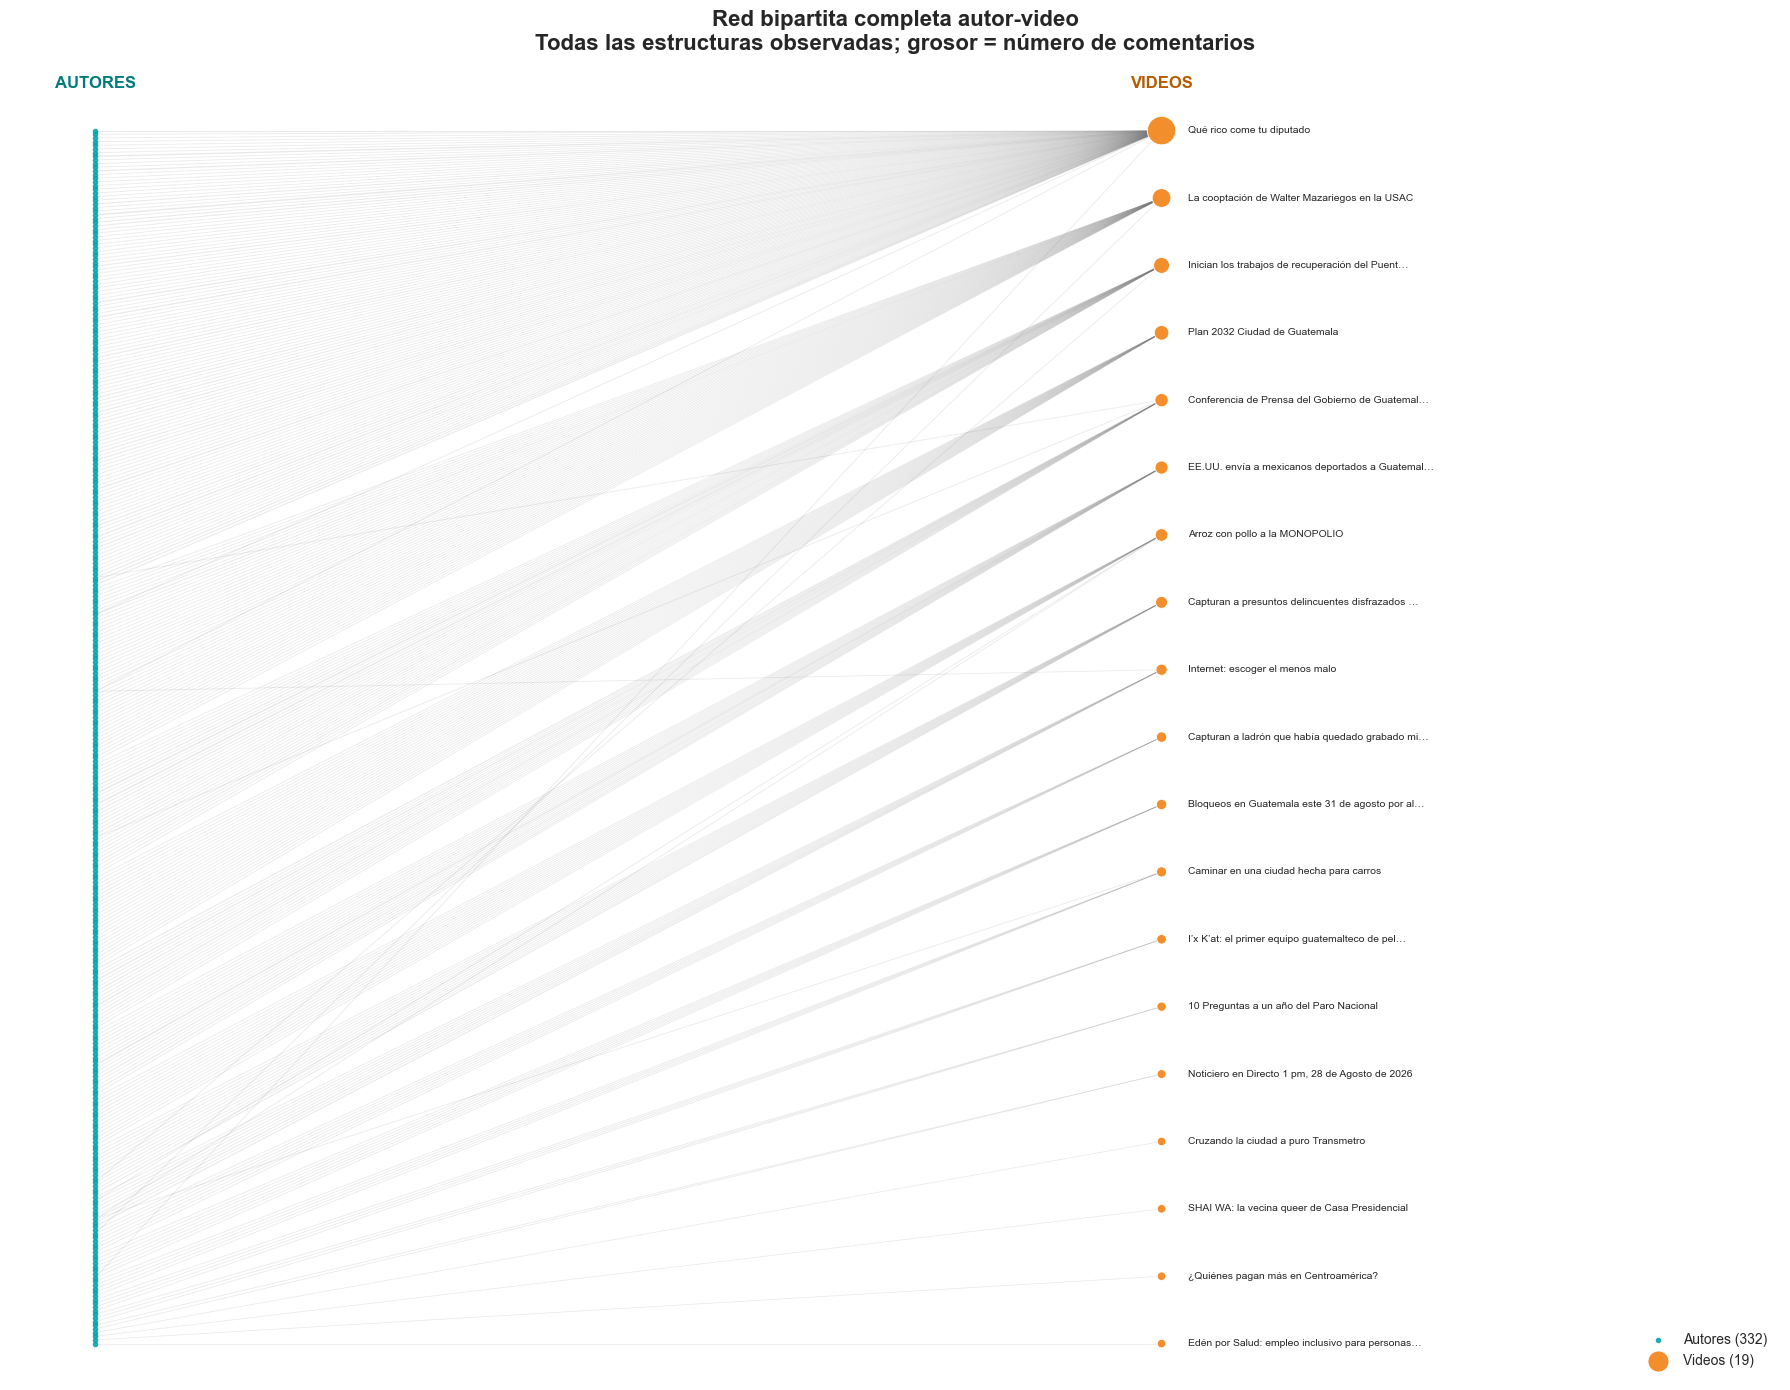

In [9]:
# Ordenar autores por su video principal ayuda a reducir cruces sin excluir estructuras.
principal = aristas.sort_values(["author_channel_id", "weight", "video_id"],
                                ascending=[True, False, True]).drop_duplicates("author_channel_id")
orden_video_ids = nodos_video.sort_values("comment_count", ascending=False)["video_id"].tolist()
rango_video = {vid: i for i, vid in enumerate(orden_video_ids)}
principal["rango_video"] = principal["video_id"].map(rango_video)
orden_autores = principal.sort_values(["rango_video", "author_name", "author_channel_id"])["author_channel_id"].tolist()

y_autor = {a: y for a, y in zip(orden_autores, np.linspace(1, 0, len(orden_autores)))}
y_video = {v: y for v, y in zip(orden_video_ids, np.linspace(1, 0, len(orden_video_ids)))}

fig, ax = plt.subplots(figsize=(18, 14))
for fila in aristas.itertuples(index=False):
    ax.plot([0, 1], [y_autor[fila.author_channel_id], y_video[fila.video_id]],
            color="#7A7A7A", alpha=0.16, linewidth=0.25 + 0.45*np.log1p(fila.weight), zorder=1)

ax.scatter(np.zeros(len(orden_autores)), [y_autor[a] for a in orden_autores],
           s=9, color="#00A6A6", alpha=0.85, label=f"Autores ({len(orden_autores)})", zorder=2)
tamanos_video = nodos_video.set_index("video_id").loc[orden_video_ids, "unique_authors"].to_numpy()
ax.scatter(np.ones(len(orden_video_ids)), [y_video[v] for v in orden_video_ids],
           s=35 + 3*tamanos_video, color="#F28E2B", edgecolor="white", linewidth=0.6,
           label=f"Videos ({len(orden_video_ids)})", zorder=3)

titulos = nodos_video.set_index("video_id")["title"].to_dict()
for vid in orden_video_ids:
    etiqueta = titulos[vid]
    etiqueta = etiqueta if len(etiqueta) <= 47 else etiqueta[:46] + "…"
    ax.text(1.025, y_video[vid], etiqueta, va="center", fontsize=7.5)

ax.text(0, 1.035, "AUTORES", ha="center", fontsize=12, fontweight="bold", color="#007C7C")
ax.text(1, 1.035, "VIDEOS", ha="center", fontsize=12, fontweight="bold", color="#B85B00")
ax.set_xlim(-0.08, 1.58)
ax.set_ylim(-0.03, 1.06)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title("Red bipartita completa autor-video\nTodas las estructuras observadas; grosor = número de comentarios",
             fontsize=16, fontweight="bold")
ax.legend(loc="lower right")
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()


In [10]:
# Resumen de componentes para comprobar que la visualización no ocultó subestructuras.
visitados = set()
componentes = []
for inicio in adyacencia:
    if inicio in visitados:
        continue
    cola = deque([inicio])
    visitados.add(inicio)
    comp = []
    while cola:
        actual = cola.popleft()
        comp.append(actual)
        for vecino in adyacencia[actual]:
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append(vecino)
    componentes.append(comp)

tamaños_componentes = sorted((len(c) for c in componentes), reverse=True)
print(f"Componentes observadas: {len(componentes)}")
print(f"Tamaños: {tamaños_componentes}")
print("El análisis topológico detallado corresponde al punto 6; aquí se usa como control de integridad.")


Componentes observadas: 10
Tamaños: [286, 26, 19, 5, 4, 3, 2, 2, 2, 2]
El análisis topológico detallado corresponde al punto 6; aquí se usa como control de integridad.


## 4.5 Significado preciso de una arista

Una arista indica únicamente que el `author_channel_id` publicó al menos un comentario principal
observado en el `video_id`. El peso es cuántos comentarios de esa pareja aparecen en el archivo.

La arista **no** demuestra amistad, conversación directa, aprobación, exposición completa al
contenido ni relación fuera de la plataforma. Dos autores que comentan el mismo video no quedan
conectados en esta red bipartita. `reply_count` tampoco crea aristas porque no identifica autores de
respuestas.


In [11]:
pesos = aristas["weight"].value_counts().sort_index().rename_axis("peso").reset_index(name="aristas")
print(pesos.to_string(index=False))
print(f"\nLa red contiene {len(nodos)} nodos y {len(aristas)} aristas; la suma de pesos es "
      f"{aristas['weight'].sum()}, exactamente el número de comentarios.")


 peso  aristas
    1      303
    2       28
    3        7
    4        1
    5        2
    6        2

La red contiene 351 nodos y 343 aristas; la suma de pesos es 406, exactamente el número de comentarios.


## Conclusión del punto 4

La red conserva 332 autores, 19 videos y 343 pares autor-video. Los prefijos de nodo evitan
colisiones, los pesos reconcilian los 406 comentarios y la visualización incluye las diez
componentes observadas sin recortar nodos ni enlaces por estética.
